In [93]:
import pandas as pd
import numpy as np
from scipy.fft import fft
import re

# 1. Load Data & Map
catmap = pd.read_csv("data/catmap.csv")
consDF = pd.read_parquet("data/Consumer.pqt").drop(columns=["credit_score"])
consDF = consDF.dropna(subset=['DQ_TARGET'])

acctDF = pd.read_parquet("data/Account.pqt")
trxnDF = pd.read_parquet("data/Transaction.pqt").drop_duplicates()

acctDF['balance_date'] = pd.to_datetime(acctDF['balance_date'])
trxnDF['posted_date'] = pd.to_datetime(trxnDF['posted_date'])

# 2. Filter Valid Consumers
date_stats = acctDF.groupby('prism_consumer_id')['balance_date'].agg(['min', 'max'])
valid_ids = date_stats[(date_stats['max'] - date_stats['min']).dt.days <= 2].index

consDF = consDF[consDF['prism_consumer_id'].isin(valid_ids)]
acctDF = acctDF[acctDF['prism_consumer_id'].isin(valid_ids)]
trxnDF = trxnDF[trxnDF['prism_consumer_id'].isin(valid_ids)]

# 3. Transaction Processing
trxnDF['signed_amount'] = np.where(
    trxnDF['credit_or_debit'] == 'DEBIT', 
    -trxnDF['amount'], 
    trxnDF['amount']
)
trxnDF = trxnDF.sort_values(['prism_consumer_id', 'posted_date', 'prism_transaction_id'])
trxnDF['raw_cumsum'] = trxnDF.groupby('prism_consumer_id')['signed_amount'].cumsum()

snapshot = acctDF.sort_values('balance_date').groupby('prism_consumer_id').tail(1)
snapshot = snapshot.rename(columns={'balance': 'snapshot_balance', 'balance_date': 'snapshot_date'})

df_merged = trxnDF.merge(snapshot[['prism_consumer_id', 'snapshot_date', 'snapshot_balance']], on='prism_consumer_id', how='left')

anchor = df_merged[df_merged['posted_date'] <= df_merged['snapshot_date']].groupby('prism_consumer_id')['raw_cumsum'].last().rename('cumsum_at_snapshot')
df_merged = df_merged.merge(anchor, on='prism_consumer_id', how='left')

df_merged['running_balance'] = (df_merged['raw_cumsum'] - df_merged['cumsum_at_snapshot']) + df_merged['snapshot_balance']

# 4. Merge Category Names (Handling ID vs Name)
# Assumes catmap has columns like ['category_id', 'category']
df_merged = df_merged.merge(catmap, left_on='category', right_on="category_id", how='left').drop(columns=["category_x"])
df_merged['category'] = df_merged['category_y'] # 'category' is now the Name

history_df = df_merged[[
    'prism_consumer_id', 
    'posted_date', 
    'category_id',     # ID (for masking)
    'category',        # Name (for features)
    'amount', 
    'signed_amount',
    'credit_or_debit', 
    'running_balance'
]].merge(consDF[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id', how='inner')
test_set = consDF.sample(int(consDF.shape[0] * 0.2))["prism_consumer_id"].to_list()
train_set = consDF[~consDF["prism_consumer_id"].isin(test_set)]["prism_consumer_id"].to_list()
final = history_df[history_df["prism_consumer_id"].isin(test_set)]
history_df = history_df[history_df["prism_consumer_id"].isin(train_set)]


In [89]:
history_df

,prism_consumer_id,posted_date,category_id,category,amount,signed_amount,credit_or_debit,running_balance,DQ_TARGET
408,1,2021-01-15,0,SELF_TRANSFER,200.00,200.00,CREDIT,-2454.92,0.0
409,1,2021-01-15,0,SELF_TRANSFER,89.00,89.00,CREDIT,-2365.92,0.0
410,1,2021-01-15,3,PAYCHECK,807.28,807.28,CREDIT,-1558.64,0.0
411,1,2021-01-15,0,SELF_TRANSFER,89.00,-89.00,DEBIT,-1647.64,0.0
412,1,2021-01-15,16,GENERAL_MERCHANDISE,33.88,-33.88,DEBIT,-1681.52,0.0
...,...,...,...,...,...,...,...,...,...
4098011,999,2021-03-11,16,GENERAL_MERCHANDISE,30.00,-30.00,DEBIT,484.31,0.0
4098012,999,2021-03-12,19,ATM_CASH,20.00,-20.00,DEBIT,464.31,0.0
4098013,999,2021-03-12,14,FOOD_AND_BEVERAGES,4.16,-4.16,DEBIT,460.15,0.0
4098014,999,2021-03-12,4,MISCELLANEOUS,63.00,-63.00,DEBIT,397.15,0.0


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_tran

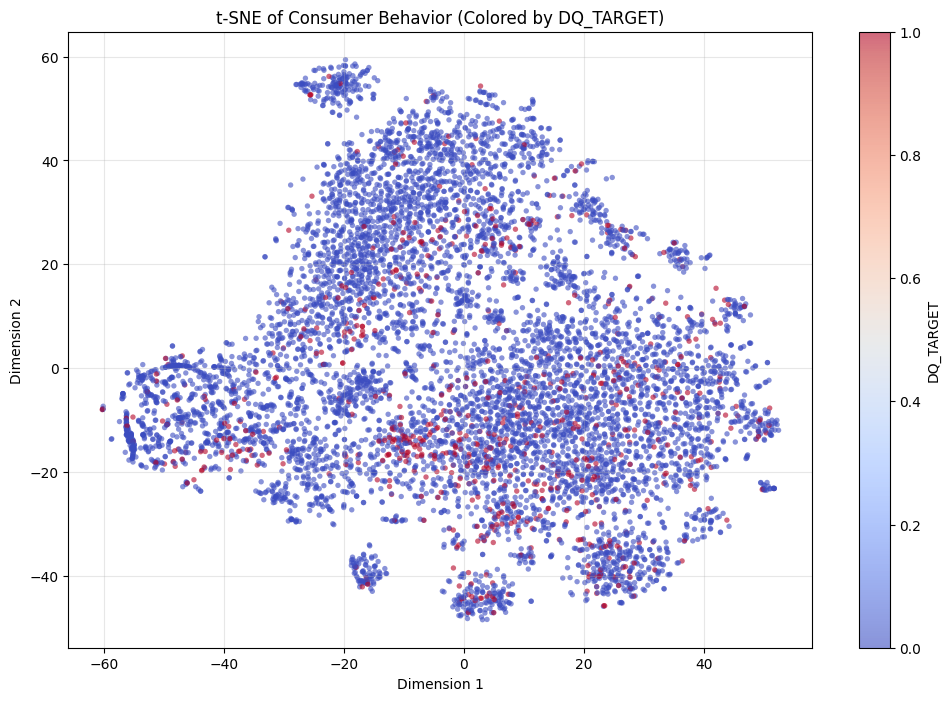

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

tsne = history_df.copy()
tsne['posted_date'] = pd.to_datetime(tsne['posted_date'])
tsne['weekday'] = tsne['posted_date'].dt.weekday
tsne['day_of_month'] = tsne['posted_date'].dt.day

def get_period(day):
    if day <= 10: return 'START'
    elif day <= 20: return 'MID'
    else: return 'END'

tsne['period'] = tsne['day_of_month'].apply(get_period)

cols = ['prism_consumer_id', 'category', 'amount', 'weekday', 'period', 'DQ_TARGET']
df_clean = tsne[cols].copy()

pivot_weekday = pd.pivot_table(
    df_clean, index='prism_consumer_id', columns=['category', 'weekday'], 
    values='amount', aggfunc='sum', fill_value=0
)
pivot_weekday.columns = [f"{cat}_WD_{wd}" for cat, wd in pivot_weekday.columns]

pivot_period = pd.pivot_table(
    df_clean, index='prism_consumer_id', columns=['category', 'period'], 
    values='amount', aggfunc='sum', fill_value=0
)
pivot_period.columns = [f"{cat}_{per}" for cat, per in pivot_period.columns]

X = pd.concat([pivot_weekday, pivot_period], axis=1).fillna(0)

y = df_clean.groupby('prism_consumer_id')['DQ_TARGET'].max()
y = y.reindex(X.index).fillna(0)

X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=50,
    early_exaggeration=12,
    init='pca',
    learning_rate='auto',
    random_state=42,
    n_jobs=-1
)

X_embedded = tsne.fit_transform(X_pca)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    c=y, 
    cmap='coolwarm', 
    alpha=0.6, 
    s=15, 
    edgecolor='none'
)
plt.colorbar(scatter, label='DQ_TARGET')
plt.title('t-SNE of Consumer Behavior (Colored by DQ_TARGET)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_tran

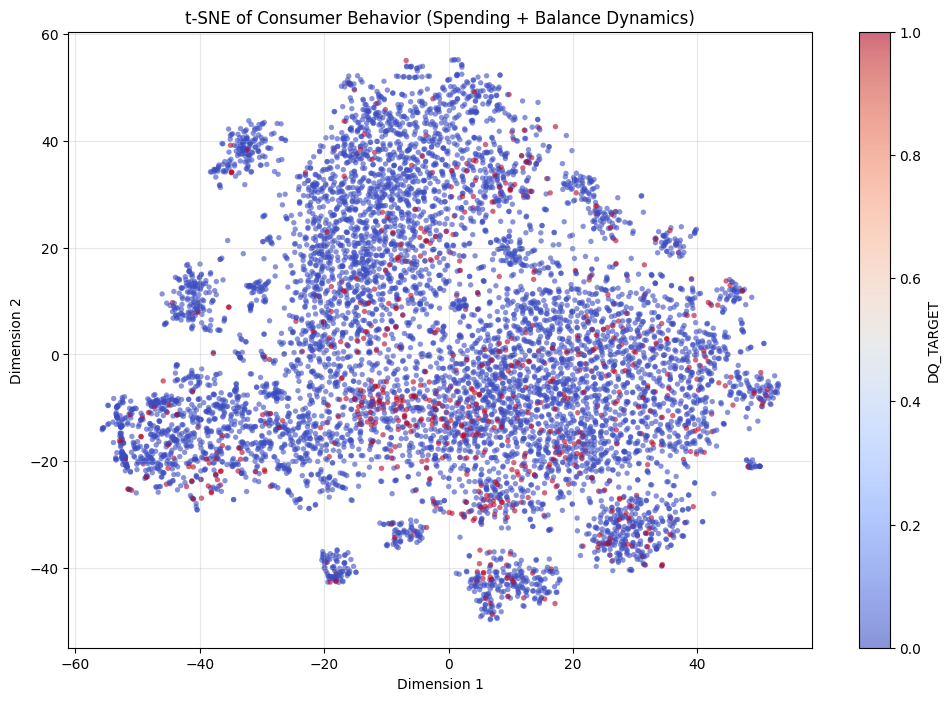

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

df = history_df.copy()
df['posted_date'] = pd.to_datetime(df['posted_date'])
df['weekday'] = df['posted_date'].dt.weekday
df['day_of_month'] = df['posted_date'].dt.day

def get_period(day):
    if day <= 10: return 'START'
    elif day <= 20: return 'MID'
    else: return 'END'

df['period'] = df['day_of_month'].apply(get_period)

cols = ['prism_consumer_id', 'category', 'amount', 'weekday', 'period', 'DQ_TARGET', 'running_balance']
df_clean = df[cols].copy()

pivot_weekday = pd.pivot_table(
    df_clean, index='prism_consumer_id', columns=['category', 'weekday'], 
    values='amount', aggfunc='sum', fill_value=0
)
pivot_weekday.columns = [f"{cat}_WD_{wd}" for cat, wd in pivot_weekday.columns]

pivot_period = pd.pivot_table(
    df_clean, index='prism_consumer_id', columns=['category', 'period'], 
    values='amount', aggfunc='sum', fill_value=0
)
pivot_period.columns = [f"{cat}_{per}" for cat, per in pivot_period.columns]

pivot_balance = pd.pivot_table(
    df_clean, index='prism_consumer_id', columns='period',
    values='running_balance', aggfunc=['mean', 'min']
)
pivot_balance.columns = [f"Bal_{func}_{per}" for func, per in pivot_balance.columns]
pivot_balance['Bal_Volatility'] = df_clean.groupby('prism_consumer_id')['running_balance'].std()

X_spending = pd.concat([pivot_weekday, pivot_period], axis=1).fillna(0)
X_balance = pivot_balance.reindex(X_spending.index).fillna(0)

X_spending_log = np.log1p(X_spending)
X_balance_log = X_balance.apply(lambda x: np.sign(x) * np.log1p(np.abs(x)))

X_final = pd.concat([X_spending_log, X_balance_log], axis=1)

y = df_clean.groupby('prism_consumer_id')['DQ_TARGET'].max()
y = y.reindex(X_final.index).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=50,
    early_exaggeration=12,
    init='pca',
    learning_rate='auto',
    random_state=42,
    n_jobs=-1
)

X_embedded = tsne.fit_transform(X_pca)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    c=y, 
    cmap='coolwarm', 
    alpha=0.6, 
    s=15, 
    edgecolor='none'
)
plt.colorbar(scatter, label='DQ_TARGET')
plt.title('t-SNE of Consumer Behavior (Spending + Balance Dynamics)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

Using Device: mps
Filtering: Keeping 7519/7914 users with >= 15 transactions
1. Embedding Training...
Epoch 0, Loss R: 0.0197
Epoch 10, Loss R: 0.0188
Epoch 20, Loss R: 0.0187
Epoch 30, Loss R: 0.0107
Epoch 40, Loss R: 0.0014
2. Supervised Training...
Epoch 0, Loss S: 0.1723
Epoch 10, Loss S: 0.1691
Epoch 20, Loss S: 0.1676
Epoch 30, Loss S: 0.1687
Epoch 40, Loss S: 0.1672
3. Joint Training...
Epoch 0: G_loss=21.5884, D_loss=0.9330
Epoch 10: G_loss=25.4595, D_loss=0.1385
Epoch 20: G_loss=26.3658, D_loss=0.1079
Epoch 30: G_loss=25.5607, D_loss=0.1344
Epoch 40: G_loss=25.4325, D_loss=0.1312


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ =

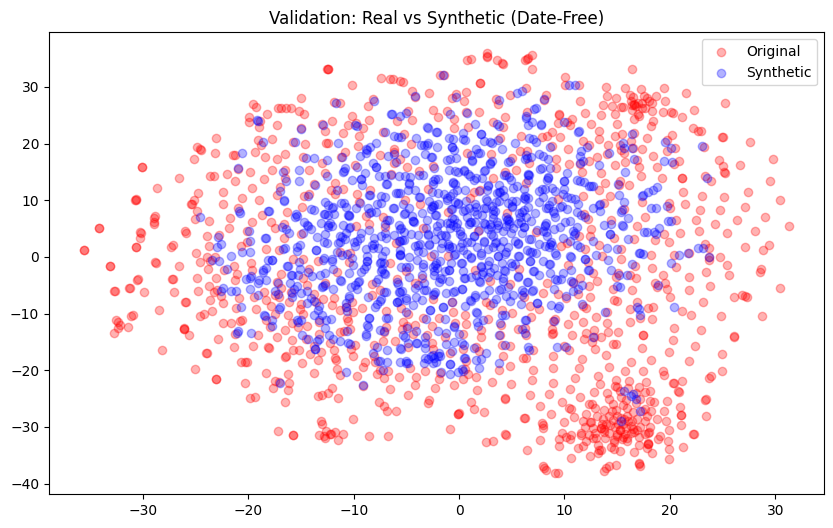

Generating Balanced DataFrame...
Gap to fill: 6526 users
Final Balanced DF Shape: (3428841, 8)
DQ_TARGET
0.0    3041179
1.0     387662
Name: count, dtype: int64
Date Sample check:
count                           387662
mean     2022-08-08 02:39:51.852696320
min                2020-07-06 00:00:00
25%                2021-10-14 00:00:00
50%                2022-11-24 00:00:00
75%                2023-06-06 00:00:00
max                2024-04-01 00:00:00
Name: posted_date, dtype: object


In [77]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using Device: {device}")

# --- 2. STRICT PREPROCESSING (DATE REMOVED) ---
def preprocess_banking_data_strict(df, seq_len=24, stride=1):
    df = df.copy()
    
    min_history = int(seq_len * 0.75) 
    user_counts = df['prism_consumer_id'].value_counts()
    valid_users = user_counts[user_counts >= min_history].index
    
    print(f"Filtering: Keeping {len(valid_users)}/{len(user_counts)} users with >= {min_history} transactions")
    df = df[df['prism_consumer_id'].isin(valid_users)].copy()
    
    # Sort by date to maintain sequence order, but we won't use the date as a feature
    df = df.sort_values(['prism_consumer_id', 'posted_date'])
    
    cat_ohe = OneHotEncoder(sparse_output=False, dtype=np.float32)
    cat_encoded = cat_ohe.fit_transform(df[['category']])
    cat_columns = [f"cat_{c}" for c in cat_ohe.get_feature_names_out(['category'])]
    
    df_encoded = pd.concat([df.reset_index(drop=True), pd.DataFrame(cat_encoded, columns=cat_columns)], axis=1)
    
    scaler = MinMaxScaler()
    # REMOVED 'days_diff' from the feature set
    continuous_cols = ['amount', 'running_balance'] 
    df_encoded[continuous_cols] = scaler.fit_transform(df_encoded[continuous_cols])
    
    feature_cols = continuous_cols + cat_columns
    
    sequences = []
    minority_ids = df[df['DQ_TARGET'] == 1]['prism_consumer_id'].unique()
    
    for user_id in minority_ids:
        user_data = df_encoded[df_encoded['prism_consumer_id'] == user_id][feature_cols].values
        
        if len(user_data) < seq_len:
            padding = np.zeros((seq_len - len(user_data), len(feature_cols)))
            sequences.append(np.vstack([padding, user_data]))
        else:
            for i in range(0, len(user_data) - seq_len + 1, stride):
                seq = user_data[i : i + seq_len]
                sequences.append(seq)
                
    return np.array(sequences), scaler, cat_ohe, feature_cols

# --- LOAD DATA ---
seq_len = 20
minority_data, scaler, cat_ohe, feature_cols = preprocess_banking_data_strict(history_df, seq_len, stride=2)

real_data_tensor = torch.FloatTensor(minority_data)
input_dim = real_data_tensor.shape[2]
hidden_dim = 64
batch_size = 1024

dataset = TensorDataset(real_data_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=False)

# --- MODELS (SAME AS BEFORE) ---
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, x):
        h, _ = self.rnn(x)
        return torch.sigmoid(self.fc(h))

class Recovery(nn.Module):
    def __init__(self, hidden_dim, input_dim):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, input_dim)
    def forward(self, h):
        x_tilde, _ = self.rnn(h)
        return torch.sigmoid(self.fc(x_tilde))

class Generator(nn.Module):
    def __init__(self, noise_dim, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(noise_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, z):
        h_hat, _ = self.rnn(z)
        return torch.sigmoid(self.fc(h_hat))

class Discriminator(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, h):
        y_hat, _ = self.rnn(h)
        return self.fc(y_hat)

embedder = Embedder(input_dim, hidden_dim).to(device)
recovery = Recovery(hidden_dim, input_dim).to(device)
generator = Generator(hidden_dim, hidden_dim).to(device)
discriminator = Discriminator(hidden_dim).to(device)

opt_er = torch.optim.Adam(list(embedder.parameters()) + list(recovery.parameters()), lr=0.001)
opt_g = torch.optim.Adam(generator.parameters(), lr=0.001)
opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.001)

# --- TRAINING LOOP ---
print("1. Embedding Training...")
for epoch in range(50):
    for batch_idx, (X_batch,) in enumerate(dataloader):
        X_batch = X_batch.to(device)
        opt_er.zero_grad()
        h = embedder(X_batch)
        x_tilde = recovery(h)
        loss_r = torch.mean((X_batch - x_tilde)**2)
        loss_r.backward()
        opt_er.step()
    if epoch % 10 == 0: print(f"Epoch {epoch}, Loss R: {loss_r.item():.4f}")

print("2. Supervised Training...")
for epoch in range(50):
    for batch_idx, (X_batch,) in enumerate(dataloader):
        X_batch = X_batch.to(device)
        opt_g.zero_grad()
        h_real = embedder(X_batch).detach()
        h_hat_super = generator(h_real[:, :-1, :])
        loss_s = torch.mean((h_hat_super - h_real[:, 1:, :])**2)
        loss_s.backward()
        opt_g.step()
    if epoch % 10 == 0: print(f"Epoch {epoch}, Loss S: {loss_s.item():.4f}")

print("3. Joint Training...")
# Re-balancing for better overlap based on your previous logs
eta_weight = 50 
lambda_weight = 1 

for epoch in range(50):
    for batch_idx, (X_batch,) in enumerate(dataloader):
        X_batch = X_batch.to(device)
        batch_curr_size = X_batch.shape[0]
        
        for _ in range(2):
            z = torch.randn(batch_curr_size, seq_len, hidden_dim, device=device)
            opt_g.zero_grad()
            h_fake = generator(z)
            d_fake = discriminator(h_fake)
            loss_u = -torch.mean(torch.log(torch.sigmoid(d_fake) + 1e-8))
            h_real = embedder(X_batch).detach()
            h_hat_super = generator(h_real[:, :-1, :])
            loss_s = torch.mean((h_hat_super - h_real[:, 1:, :])**2)
            x_hat = recovery(h_fake)
            loss_v = torch.mean(torch.abs(torch.std(x_hat, dim=0) - torch.std(X_batch, dim=0)))
            loss_g = loss_u + eta_weight * torch.sqrt(loss_s) + lambda_weight * loss_v
            loss_g.backward()
            opt_g.step()

        opt_d.zero_grad()
        h_real = embedder(X_batch).detach()
        z = torch.randn(batch_curr_size, seq_len, hidden_dim, device=device)
        h_fake = generator(z).detach()
        d_real = discriminator(h_real)
        d_fake_det = discriminator(h_fake)
        loss_d = -torch.mean(torch.log(torch.sigmoid(d_real) + 1e-8) + 
                             torch.log(1. - torch.sigmoid(d_fake_det) + 1e-8))
        if loss_d > 0.15: # D-Throttling to maintain gradient quality
            loss_d.backward()
            opt_d.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: G_loss={loss_g.item():.4f}, D_loss={loss_d.item():.4f}")

# --- VISUALIZATION ---
real_flat = real_data_tensor.cpu().numpy().reshape(real_data_tensor.shape[0], -1)
num_gen = min(len(real_flat), 1000)
z = torch.randn(num_gen, seq_len, hidden_dim, device=device)
with torch.no_grad():
    synthetic_h = generator(z)
    synthetic_data = recovery(synthetic_h).cpu().numpy()

synth_flat = synthetic_data.reshape(num_gen, -1)
idx = np.random.choice(len(real_flat), num_gen, replace=False)
real_flat = real_flat[idx]

combined_data = np.concatenate([real_flat, synth_flat], axis=0)
labels = np.array([0] * num_gen + [1] * num_gen)

tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(combined_data)

plt.figure(figsize=(10, 6))
plt.scatter(tsne_results[labels==0, 0], tsne_results[labels==0, 1], c='red', alpha=0.3, label='Original')
plt.scatter(tsne_results[labels==1, 0], tsne_results[labels==1, 1], c='blue', alpha=0.3, label='Synthetic')
plt.legend()
plt.title('Validation: Real vs Synthetic (Date-Free)')
plt.show()

# --- BALANCED DF GENERATION (WITH DATE FIX) ---
print("Generating Balanced DataFrame...")
# 1. Identify Gap
num_majority = len(history_df[history_df['DQ_TARGET'] == 0]['prism_consumer_id'].unique())
num_minority = len(history_df[history_df['DQ_TARGET'] == 1]['prism_consumer_id'].unique())
gap = num_majority - num_minority
print(f"Gap to fill: {gap} users")

# 2. Generate Synthetic Data
z_gap = torch.randn(gap, seq_len, hidden_dim, device=device)
with torch.no_grad():
    synthetic_raw = recovery(generator(z_gap)).cpu().numpy()

# 3. Inverse Transform & Reconstruct
flat_synth = synthetic_raw.reshape(-1, len(feature_cols))
n_cont = 2 # amount, running_balance
unscaled_cont = scaler.inverse_transform(flat_synth[:, :n_cont])

# Recover categories
cat_data = flat_synth[:, n_cont:]
cat_indices = np.argmax(cat_data, axis=1)
cat_names = cat_ohe.categories_[0][cat_indices]

# 4. Build Synthetic DataFrame
synthetic_df = pd.DataFrame(unscaled_cont, columns=['amount', 'running_balance'])
synthetic_df['category'] = cat_names
synthetic_df['DQ_TARGET'] = 1.0

# Assign new unique IDs
start_id = history_df['prism_consumer_id'].max() + 1
synthetic_df['prism_consumer_id'] = np.repeat(np.arange(start_id, start_id + gap), seq_len)

# --- KEY FIX: DATE REDISTRIBUTION ---
# We assign a random START DATE for each user from the real range,
# then increment by 1 day per sequence step to mimic real history.
real_min_date = history_df['posted_date'].min()
real_max_date = history_df['posted_date'].max()
days_range = (real_max_date - real_min_date).days - seq_len

# Random start offsets for each unique synthetic user
random_offsets = np.random.randint(0, days_range, size=gap)
user_start_dates = [real_min_date + pd.Timedelta(days=d) for d in random_offsets]

# Expand to per-row dates (User Start + 0 days, + 1 day, ...)
row_base_dates = np.repeat(user_start_dates, seq_len)
time_deltas = np.tile(np.arange(seq_len), gap) # [0,1,2... 0,1,2...]
synthetic_df['posted_date'] = pd.to_datetime(row_base_dates) + pd.to_timedelta(time_deltas, unit='D')

# 5. Reconstruct Logic (Credit/Debit/Signed Amount)
cat_map = history_df.drop_duplicates('category').set_index('category')['credit_or_debit'].to_dict()
synthetic_df['credit_or_debit'] = synthetic_df['category'].map(cat_map).fillna('DEBIT')

synthetic_df['signed_amount'] = np.where(
    synthetic_df['credit_or_debit'] == 'DEBIT', 
    -synthetic_df['amount'], 
    synthetic_df['amount']
)

# 6. Final Merge
cols_to_keep = ['prism_consumer_id', 'posted_date', 'category', 'amount', 'signed_amount', 'credit_or_debit', 'running_balance', 'DQ_TARGET']
balanced_df = pd.concat([history_df[cols_to_keep], synthetic_df[cols_to_keep]], axis=0).reset_index(drop=True)

print(f"Final Balanced DF Shape: {balanced_df.shape}")
print(balanced_df['DQ_TARGET'].value_counts())
print("Date Sample check:")
print(balanced_df[balanced_df['DQ_TARGET']==1]['posted_date'].describe())

In [80]:
balanced_df[['prism_consumer_id', 'DQ_TARGET']].groupby("prism_consumer_id").max().value_counts()

DQ_TARGET
0.0          7220
1.0          7220
Name: count, dtype: int64

In [85]:
# --- SANITATION BLOCK (Run this before Feature Extraction) ---

# 1. Clip Financial Extremes to Realistic Limits
# Prevents the GAN from hallucinating billion-dollar transactions that crash LR
financial_cols = ['amount', 'signed_amount', 'running_balance']
for col in financial_cols:
    if col in balanced_df.columns:
        # Clip between -1 Million and +1 Million
        balanced_df[col] = balanced_df[col].clip(lower=-1e6, upper=1e6)

# 2. Check for NaNs or Infinite values
print(f"NaNs before clean: {balanced_df.isna().sum().sum()}")
balanced_df = balanced_df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Balanced DF shape after cleaning: {balanced_df.shape}")

# 3. Verify Synthetic Data Distribution
# If 'max' is still huge, your scaler/inverse_transform logic might need checking
print("Synthetic Data Stats:")
print(balanced_df[balanced_df['DQ_TARGET'] == 1][['amount', 'running_balance']].describe())

NaNs before clean: 944
Balanced DF shape after cleaning: (3427897, 8)
Synthetic Data Stats:
              amount  running_balance
count  387662.000000    387662.000000
mean      653.912460      1798.971193
std      1396.914299     10658.771483
min         0.000000    -44032.019531
25%        17.842500      -114.787500
50%        89.990000       687.595000
75%      1258.334351      3281.345000
max    345600.000000    398353.860000


In [86]:
balanced_df[['prism_consumer_id', 'DQ_TARGET']].groupby("prism_consumer_id").max().value_counts()

DQ_TARGET
1.0          7220
0.0          7198
Name: count, dtype: int64

In [87]:
import pandas as pd
import numpy as np
import time

def extract_consumer_habits(df):
    total_start = time.time()
    df = df.copy()
    df['posted_date'] = pd.to_datetime(df['posted_date'])
    
    # 1. Setup Temporal Columns
    df['day_name'] = df['posted_date'].dt.day_name().str.lower()
    df['day_of_month'] = df['posted_date'].dt.day
    
    # --- PART A1: Weekly Time-Domain ---
    start = time.time()
    day_avg = df.groupby(['prism_consumer_id', 'category', 'day_name'])['signed_amount'].mean().reset_index()
    weekly_pivot = day_avg.pivot_table(
        index='prism_consumer_id', 
        columns=['category', 'day_name'], 
        values='signed_amount'
    ).fillna(0)
    weekly_pivot.columns = [f"cat_{c}_{d}" for c, d in weekly_pivot.columns]
    print(f"Latency (Weekly Domain): {time.time() - start:.4f}s")

    # --- PART A2: Monthly Time-Domain ---
    start = time.time()
    dom_avg = df.groupby(['prism_consumer_id', 'category', 'day_of_month'])['signed_amount'].mean().reset_index()
    monthly_pivot = dom_avg.pivot_table(
        index='prism_consumer_id', 
        columns=['category', 'day_of_month'], 
        values='signed_amount'
    ).fillna(0)
    monthly_pivot.columns = [f"cat_{c}_dom_{d}" for c, d in monthly_pivot.columns]
    print(f"Latency (Monthly Domain): {time.time() - start:.4f}s")

    # --- PART B: Dual-Frequency FFT ---
    start = time.time()
    def get_dual_fft_power(series):
        if len(series) < 14 or series.sum() == 0:
            return 0, 0
        vals = series.values - series.mean()
        fft_mag = np.abs(np.fft.rfft(vals))
        fft_freq = np.fft.rfftfreq(len(vals), d=1)
        
        weekly_idx = np.argmin(np.abs(fft_freq - (1/7)))
        weekly_power = fft_mag[weekly_idx]
        
        monthly_power = 0
        if len(series) >= 28:
            monthly_idx = np.argmin(np.abs(fft_freq - (1/30)))
            monthly_power = fft_mag[monthly_idx]
            
        return weekly_power, monthly_power

    fft_results = []
    for (cons_id, cat), group in df.groupby(['prism_consumer_id', 'category']):
        daily_series = group.groupby('posted_date')['signed_amount'].sum()
        full_range = pd.date_range(daily_series.index.min(), daily_series.index.max())
        series = daily_series.reindex(full_range, fill_value=0)
        w_power, m_power = get_dual_fft_power(series)
        fft_results.append({
            'prism_consumer_id': cons_id,
            'category': cat,
            'fft_weekly_habit': w_power,
            'fft_monthly_habit': m_power
        })

    fft_df = pd.DataFrame(fft_results)
    fft_pivot_w = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_weekly_habit').fillna(0)
    fft_pivot_w.columns = [f"cat_{c}_fft_weekly" for c in fft_pivot_w.columns]
    
    fft_pivot_m = fft_df.pivot(index='prism_consumer_id', columns='category', values='fft_monthly_habit').fillna(0)
    fft_pivot_m.columns = [f"cat_{c}_fft_monthly" for c in fft_pivot_m.columns]
    print(f"Latency (FFT Processing): {time.time() - start:.4f}s")

    # --- PART C: Merge All Features (Optimized) ---
    start = time.time()
    target_map = df.groupby('prism_consumer_id')['DQ_TARGET'].first()
    
    # Use list concatenation to avoid fragmentation warnings
    final_df = pd.concat([weekly_pivot, monthly_pivot, fft_pivot_w, fft_pivot_m], axis=1)
    final_df = final_df.join(target_map)
    print(f"Latency (Feature Merging): {time.time() - start:.4f}s")
    
    print(f"Total Processing Latency: {time.time() - total_start:.4f}s")
    return final_df

habit_features_df = extract_consumer_habits(balanced_df)

Latency (Weekly Domain): 0.3915s
Latency (Monthly Domain): 0.5691s
Latency (FFT Processing): 47.8792s
Latency (Feature Merging): 0.1113s
Total Processing Latency: 49.3782s


In [82]:
import xgboost as xgb
import numpy as np
import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

test_df_raw = final 

X_train_full = habit_features_df
X_test_full = extract_consumer_habits(test_df_raw)

cols_to_drop = ['DQ_TARGET', 'posted_date', 'prism_consumer_id']

X_train = X_train_full.drop(columns=cols_to_drop, errors='ignore')
y_train = X_train_full['DQ_TARGET']

X_test = X_test_full.drop(columns=cols_to_drop, errors='ignore')
y_test = X_test_full['DQ_TARGET']

model_features = X_train.columns
X_test = X_test.reindex(columns=model_features, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_train_probs = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"LR Train ROC AUC: {roc_auc_score(y_train, lr_train_probs):.4f}")
print(f"LR Test ROC AUC:  {roc_auc_score(y_test, lr_test_probs):.4f}")

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGB Train ROC AUC: {roc_auc_score(y_train, xgb_train_probs):.4f}")
print(f"XGB Test ROC AUC:  {roc_auc_score(y_test, xgb_test_probs):.4f}")

Latency (Weekly Domain): 0.0898s
Latency (Monthly Domain): 0.1223s
Latency (FFT Processing): 7.3354s
Latency (Feature Merging): 0.0252s
Total Processing Latency: 7.6930s


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/kylechoi/Desktop/Desktop - ky

LR Train ROC AUC: 0.9961
LR Test ROC AUC:  0.5508
XGB Train ROC AUC: 0.9968
XGB Test ROC AUC:  0.6955


/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kylechoi/Desktop/Desktop - kyle의 MacBook Pro/DSC180B/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


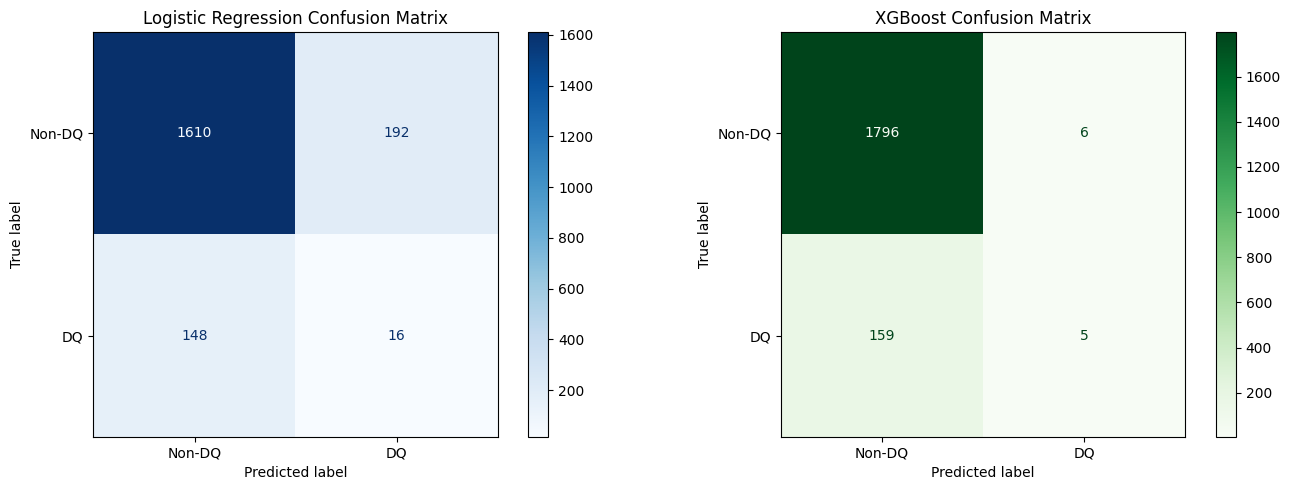

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate Binary Predictions
# Since you used class_weight='balanced' and scale_pos_weight, 
# a 0.5 threshold is a reasonable starting point.
lr_preds = lr_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test)

# 2. Compute Matrices
cm_lr = confusion_matrix(y_test, lr_preds)
cm_xgb = confusion_matrix(y_test, xgb_preds)

# 3. Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm_lr, display_labels=['Non-DQ', 'DQ']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Logistic Regression Confusion Matrix')

ConfusionMatrixDisplay(cm_xgb, display_labels=['Non-DQ', 'DQ']).plot(ax=ax[1], cmap='Greens')
ax[1].set_title('XGBoost Confusion Matrix')

plt.tight_layout()
plt.show()

In [23]:

xgb_latencies = []
for i in range(min(len(X_test), 1000)):
    row = X_test.iloc[i:i+1]
    start_time = time.perf_counter()
    _ = xgb_model.predict_proba(row)
    xgb_latencies.append(time.perf_counter() - start_time)

print(f"XGB Average Latency: {np.mean(xgb_latencies):.6f}s")

XGB Average Latency: 0.034620s


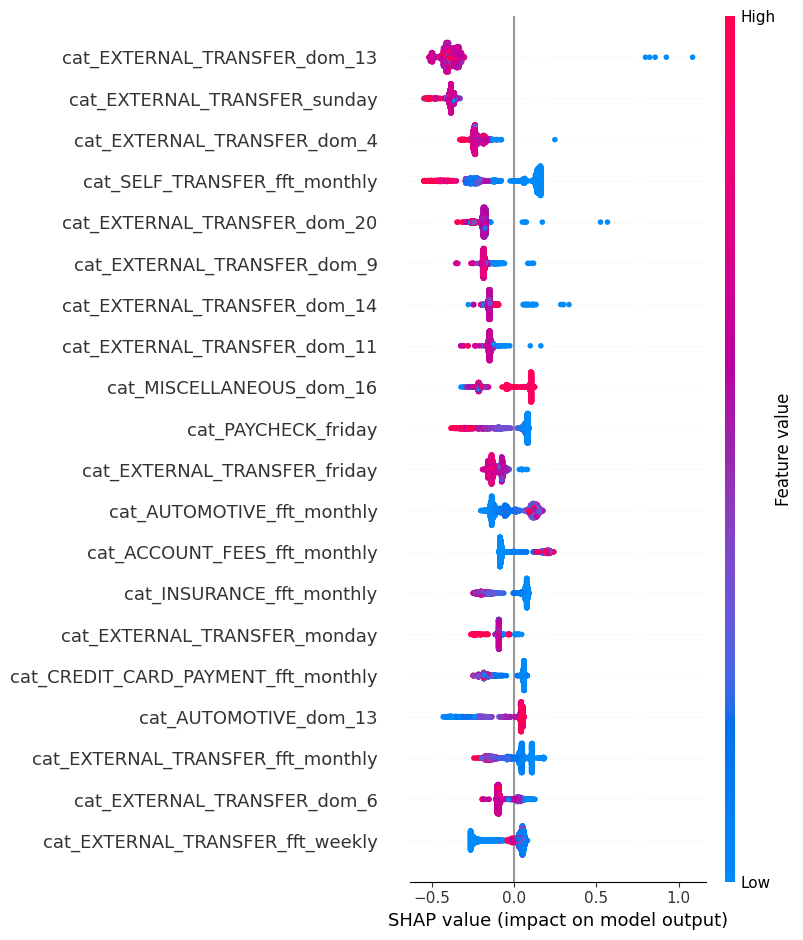

In [52]:
import shap
import numpy as np
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=20)

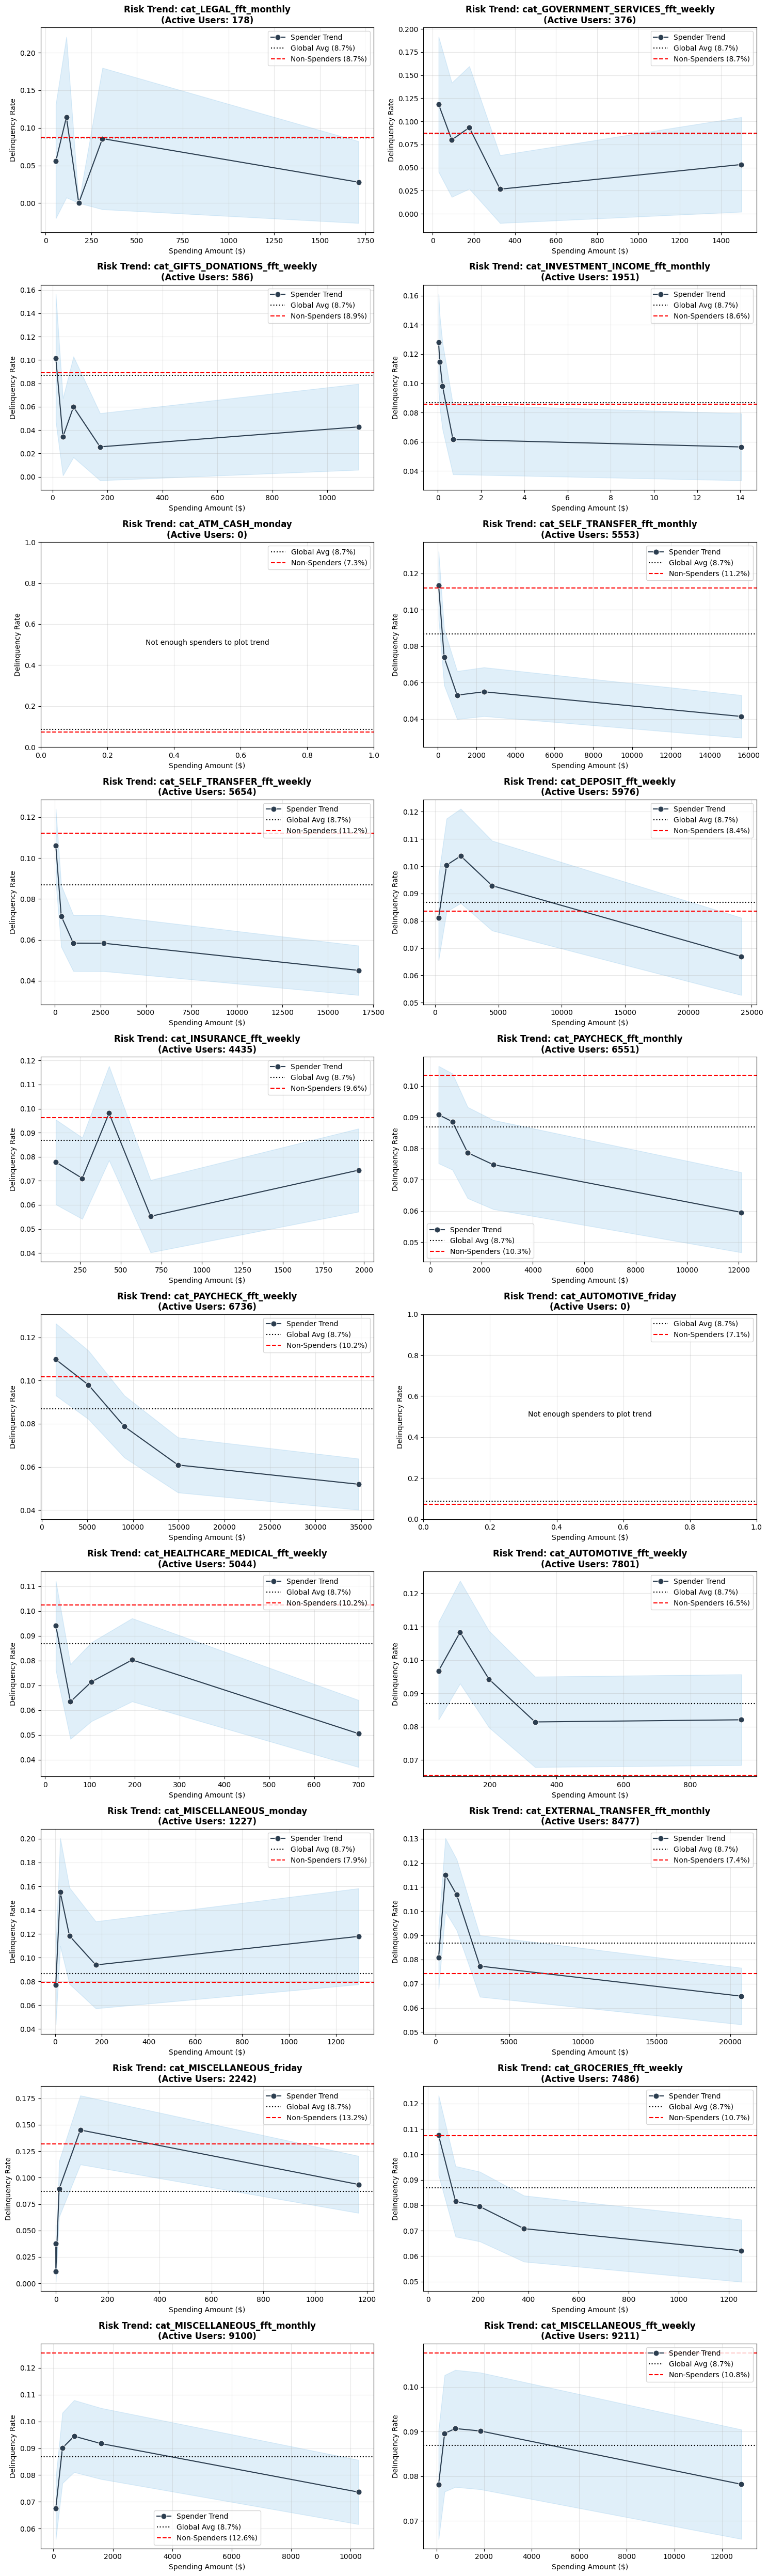

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

features_to_check = importance_df.head(20)['Feature'].to_list()

sparsity_check = []
for col in features_to_check:
    non_zeros = (habit_features_df[col] != 0).sum()
    total = len(habit_features_df)
    pct_active = non_zeros / total
    
    sparsity_check.append({
        'Feature': col,
        'Active_Users': non_zeros,
        'Pct_Active': f"{pct_active:.1%}",
        'Verdict': 'KEEP' if non_zeros > 100 else 'DROP / FLAG'
    })

sparsity_df = pd.DataFrame(sparsity_check).sort_values('Active_Users')

def plot_risk_trends_nonzero(df, features, target='DQ_TARGET', q=5):
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for i, col in enumerate(features):
        ax = axes[i]
        zeros = df[df[col] == 0]
        non_zeros = df[df[col] > 0].copy()
        
        global_risk = df[target].mean()
        zero_risk = zeros[target].mean()
        
        if len(non_zeros) > 50:
            try:
                non_zeros['bin'] = pd.qcut(non_zeros[col], q=q, duplicates='drop')
            except ValueError:
                 non_zeros['bin'] = pd.qcut(non_zeros[col].rank(method='first'), q=q)
                 
            agg_data = non_zeros.groupby('bin', observed=True).agg({
                col: 'mean',
                target: ['mean', 'sem', 'count']
            })
            agg_data.columns = ['avg_spend', 'risk_rate', 'std_err', 'count']
            agg_data = agg_data.reset_index()

            sns.lineplot(
                ax=ax, x=agg_data['avg_spend'], y=agg_data['risk_rate'],
                marker='o', markersize=8, color='#2c3e50', label='Spender Trend'
            )
            
            lower = agg_data['risk_rate'] - 1.96 * agg_data['std_err']
            upper = agg_data['risk_rate'] + 1.96 * agg_data['std_err']
            ax.fill_between(agg_data['avg_spend'], lower, upper, color='#3498db', alpha=0.15)
        else:
            ax.text(0.5, 0.5, "Not enough spenders to plot trend", ha='center')

        ax.axhline(global_risk, color='black', linestyle=':', label=f'Global Avg ({global_risk:.1%})')
        ax.axhline(zero_risk, color='red', linestyle='--', label=f'Non-Spenders ({zero_risk:.1%})')
        
        ax.set_title(f'Risk Trend: {col}\n(Active Users: {len(non_zeros)})', fontweight='bold')
        ax.set_ylabel('Delinquency Rate')
        ax.set_xlabel('Spending Amount ($)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

sparse_features = sparsity_df["Feature"].to_list()
plot_risk_trends_nonzero(real_test_features, sparse_features)

In [ ]:
sparsity_df.sort_values(by = "Active_Users")

,Feature,Active_Users,Pct_Active,Verdict
8,cat_LEGAL_fft_monthly,1042,5.8%,KEEP
12,cat_GOVERNMENT_SERVICES_fft_weekly,2127,11.8%,KEEP
14,cat_GIFTS_DONATIONS_fft_weekly,2262,12.5%,KEEP
13,cat_INVESTMENT_INCOME_fft_monthly,3103,17.2%,KEEP
18,cat_ATM_CASH_monday,4789,26.5%,KEEP
11,cat_SELF_TRANSFER_fft_monthly,5553,30.8%,KEEP
4,cat_SELF_TRANSFER_fft_weekly,5654,31.3%,KEEP
17,cat_DEPOSIT_fft_weekly,6120,33.9%,KEEP
16,cat_INSURANCE_fft_weekly,6483,35.9%,KEEP
7,cat_PAYCHECK_fft_monthly,6551,36.3%,KEEP
